#Problem Statement

The objective of this analysis is to understand Netflix's content distribution across movies and TV shows, identify trends in content release timings, genre, countries, actors, directors and to derive insight from these analysis that can help Netflix decide what content to produce for various regions.

#Importing Python libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#Basic analysis of data

In [ ]:
netflix = pd.read_csv('netflix.csv')

In [ ]:
netflix.shape

(8807, 12)

Dataset Shape:
Rows: 8807
Columns: 12

##Missing Value detection

In [ ]:
netflix.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


##Datatypes:

1.   Categorical: type, director, cast, country, rating, listed_in
2.   Numerical: release_year
3.   Date: date_added

*   Converted date_added to datetime
*   Converted Categorical columns to category

##Missing Value Analysis:

*   Replaced missing Nan values with 'Unknown Coulmn_name' for better analysis

##Un-nesting of data:

*   Expanded coulmns which were having multiple comma separated values in a single coulmn and exploded it for better analysis. The columns include cast, director, country, listed_in.

In [ ]:
netflix['cast'] = netflix['cast'].str.split(',')
netflix['listed_in'] = netflix['listed_in'].str.split(',')
netflix['country'] = netflix['country'].str.split(',')
netflix['director'] = netflix['director'].str.split(',')
netflix = netflix.explode('cast')
netflix = netflix.explode('listed_in')
netflix = netflix.explode('country')
netflix = netflix.explode('director')
netflix['director'] = netflix['director'].fillna('Unknown Director')
netflix['cast'] = netflix['cast'].fillna('Unknown Cast')
netflix['country'] = netflix['country'].fillna('Unknown Country')
netflix['date_added'] = netflix['date_added'].fillna('Unknown Date Added')
netflix['rating'] = netflix['rating'].fillna('Unknown Rating')
netflix['duration'] = netflix['duration'].fillna('Unknown Duration')
netflix['cast'] = netflix['cast'].str.strip()
netflix['listed_in'] = netflix['listed_in'].str.strip()
netflix['country'] = netflix['country'].str.strip()
netflix['director'] = netflix['director'].str.strip()

In [ ]:
netflix.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


#1. Find the counts of each categorical variable both using graphical and nongraphical analysis.


##Content Type

###a. Non-graphical Analysis:

In [ ]:
netflix.drop_duplicates('show_id')['type'].value_counts(ascending = False)

,count
type,
Movie,6131
TV Show,2676


###b. Graphical analysis:

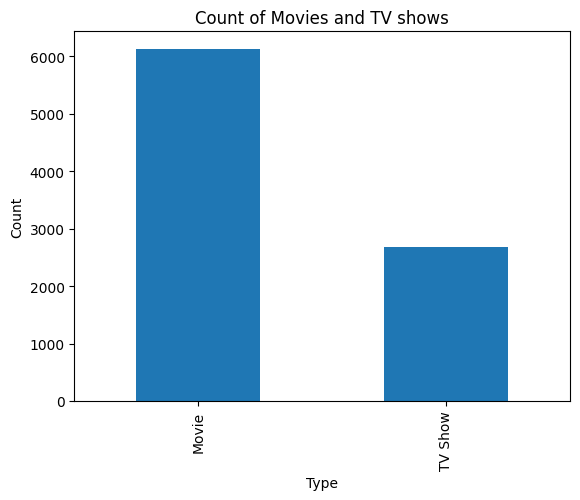

In [ ]:
netflix.drop_duplicates('show_id')['type'].value_counts().plot(kind = 'bar')
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Count of Movies and TV shows')
plt.show()


###Analysis and Interpretation

  From non graphical analysis using value counts and graphical analysis using count plot in type column, it is known that the movies is most preferred by Netflix. The number of movies in Netflix is nearly 3 times more than the TV shows. This indicates that Netflix currently focuses on movie content rather than TV shows

##Directors

###a. Non-graphical Analysis:

In [ ]:
netflix['director'].value_counts(ascending = False)

,count
director,
Unknown Director,50643
Martin Scorsese,419
Youssef Chahine,409
Cathy Garcia-Molina,356
Steven Spielberg,355
...,...
Ben Patterson,1
Jedd Wider,1
Todd Wider,1


###b. Graphical analysis:

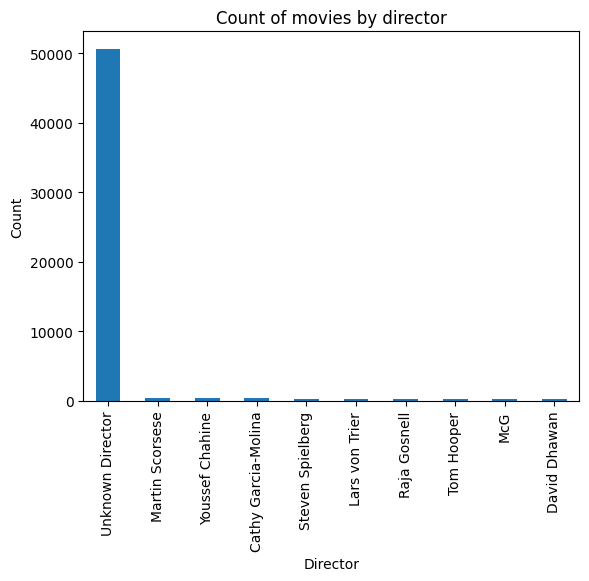

In [ ]:
netflix['director'].value_counts(ascending = False).head(10).plot(kind = 'bar')
plt.xlabel('Director')
plt.ylabel('Count')
plt.title('Count of movies by director')
plt.show()

###Analysis and Interpretation
  From the non graphical analysis using value counts and graphical analysis using count plots on 'director' column, it is known that the 'Unknown Director' category has the highest number of counts which indicates that the Netflix dataset has significant number of missing values. Excluding this category we can see that the Martin Scorsese has directed highest number of films closely followed by Youssef Chahine.

##Cast

###a. Non-graphical Analysis:

In [ ]:
netflix['cast'].value_counts(ascending = False)

,count
cast,
Unknown Cast,2149
Liam Neeson,161
Alfred Molina,160
John Krasinski,139
Salma Hayek,130
...,...
Kelis,1
Elias Toufexis,1
Claudia Christian,1


###b. Graphical Analysis:

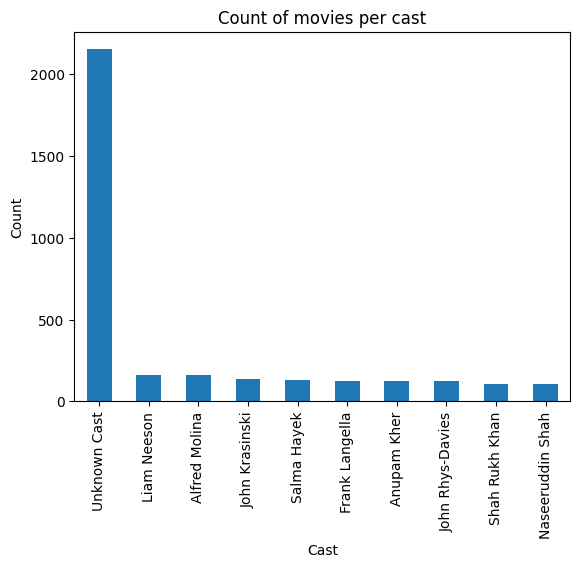

In [ ]:
netflix['cast'].value_counts(ascending = False).head(10).plot(kind = 'bar')
plt.xlabel('Cast')
plt.ylabel('Count')
plt.title('Count of movies per cast')
plt.show()

###Analysis and Interpretation
  From the Non graphical analysis using value counts and graphical analysis using count plot, it can be infered that 'Unknown Cast' dominates the dataset. This clearly indicates the presence of a significant amount of missing cast information in the netflix dataset. After excluding this category, Liam Neeson is identified as the actor who has appeared in highest number of movies, followed by Alfred Molina.

##Country

###a. Non-graphical Analysis:


In [ ]:
netflix['country'].value_counts(ascending = False)

,count
country,
United States,59350
India,22814
United Kingdom,12965
Unknown Country,11897
Japan,8679
...,...
Botswana,2
Afghanistan,2
Nicaragua,1


###b. Graphical Analysis:

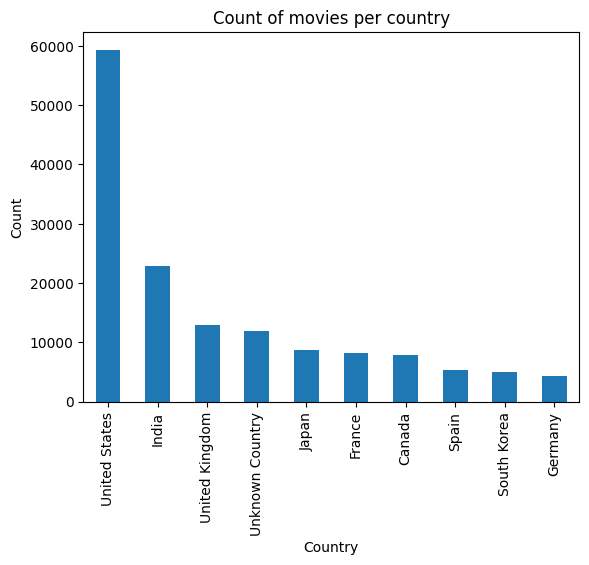

In [ ]:
netflix['country'].value_counts(ascending = False).head(10).plot(kind = 'bar')
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Count of movies per country')
plt.show()

###Analysis and Interpretation
  From non-graphical analysis using value counts and graphical analysis using count plot, it is observed that the United States has contributed the highest number of movies/tv shows to the netflix dataset. The count of movies/tv shows of the United States is nearly 3 times higher than the second ranked country, India.

##Date Added

###a. Non-graphical Analysis:

In [ ]:
netflix.drop_duplicates('show_id')['date_added'].value_counts(ascending = False)

,count
date_added,
"January 1, 2020",109
"November 1, 2019",89
"March 1, 2018",75
"December 31, 2019",74
"October 1, 2018",71
...,...
"June 1, 2018",1
"October 21, 2018",1
"February 8, 2016",1


###b. Graphical Analysis:

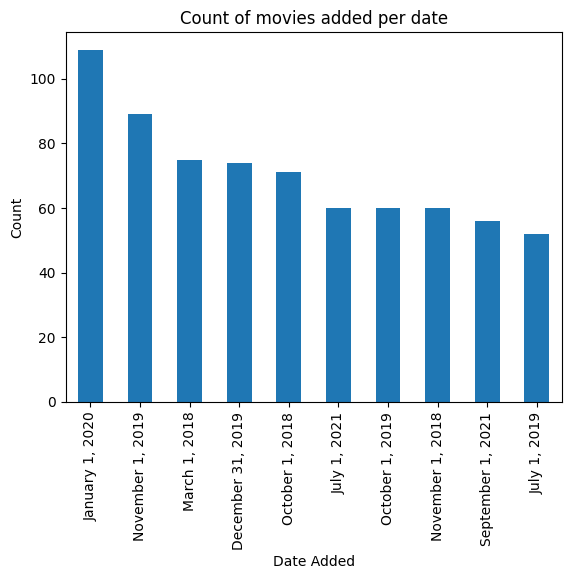

In [ ]:
netflix.drop_duplicates('show_id')['date_added'].value_counts(ascending = False).head(10).plot(kind = 'bar')
plt.xlabel('Date Added')
plt.ylabel('Count')
plt.title('Count of movies added per date')
plt.show()


















Continious Variable - Histplot

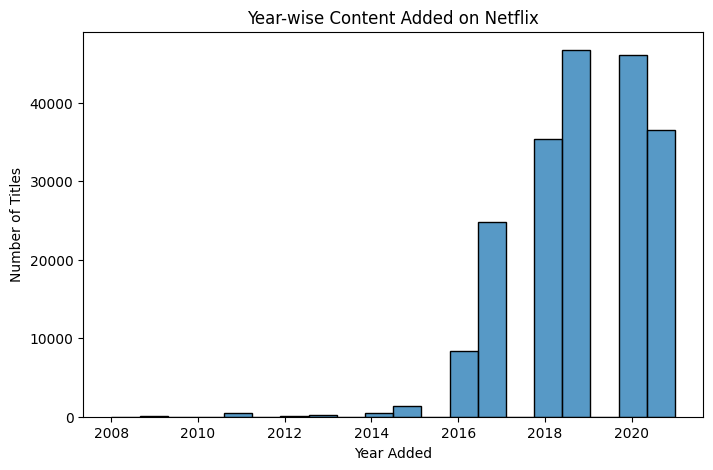

In [ ]:
netflix['date_added'] = pd.to_datetime(netflix['date_added'], errors= 'coerce')
netflix['added_year'] = netflix['date_added'].dt.year

plt.figure(figsize=(8,5))
sns.histplot(netflix['added_year'].dropna(), bins=20)
plt.title('Year-wise Content Added on Netflix')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

###Analysis and Interpretation
  From non graphical analysis using value counts and graphical analysis using count plot, it is observed that January 01, 2020 recorded highest number of movies and tv shows added to the Netflix platform. This suggests that the netflix tends to add large volume at the beginning of the year.

  The Histplot distribution shows sharp increase in the number of titles added after 2016 indicating the Netflix's rapid expansion phase.This shows the platform's aggressive growth in recent years.

##Release Year

###a. Non-graphical Analysis:

In [ ]:
netflix.drop_duplicates('show_id')['release_year'].value_counts(ascending = False)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
...,...
1961,1
1925,1
1959,1


###b. Graphical Analysis:

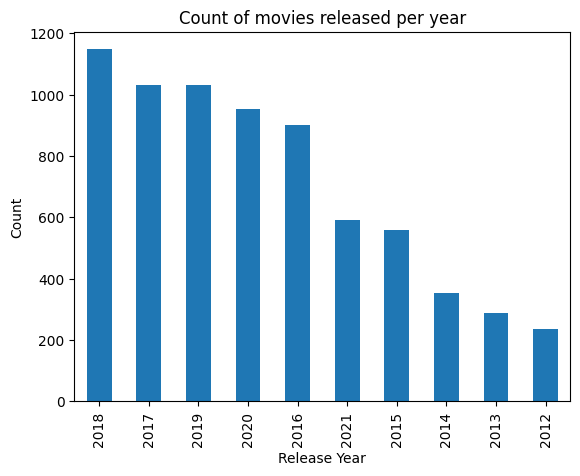

In [ ]:
netflix.drop_duplicates('show_id')['release_year'].value_counts(ascending = False).head(10).plot(kind = 'bar')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.title('Count of movies released per year')
plt.show()

Continuous Variable - Histplot

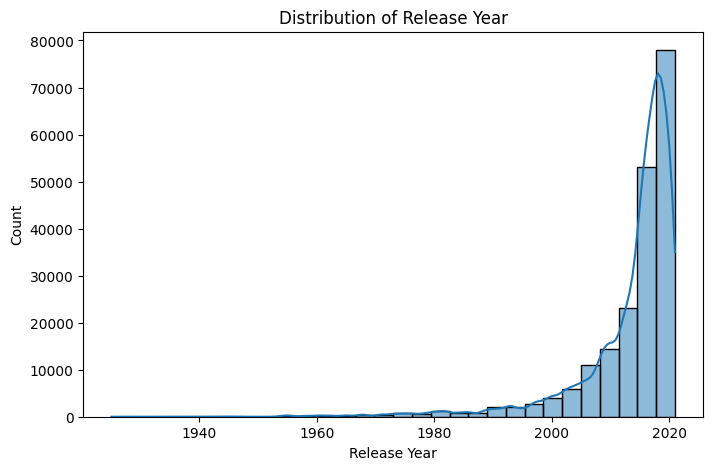

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(netflix['release_year'], bins=30, kde=True)
plt.title('Distribution of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

Categorical Variables - BoxPlot

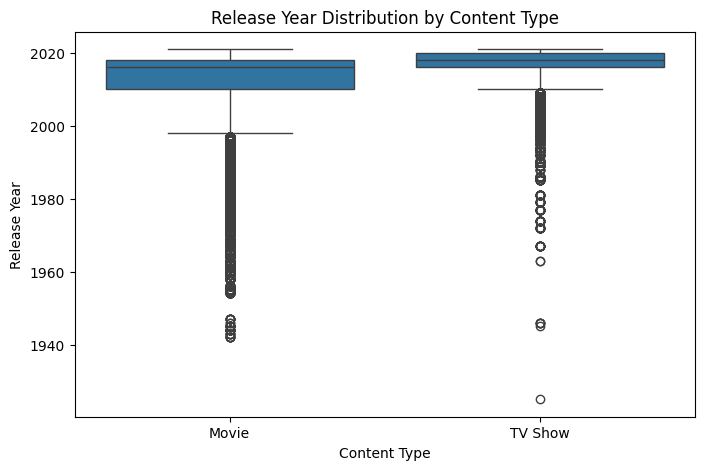

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='type', y='release_year', data=netflix)
plt.title('Release Year Distribution by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Release Year')
plt.show()

###Analysis and Interpretation
  From non graphical analysis using value counts and non graphical analysis using count plots, it is observed that the year 2018 has recorded the highest number of movie and tv show releases on Netflix.
  The Histplot shows a right skewed distribution of the release years with significant increase in the content after the year 2000. The peak in recent years indicate the Netflix's focus on accuring new content.

  The Boxplot shows that the TV shows have higher median release year when compared to movies indicating the TV shows are more recent. Movies show wider spread which indicates mix of both old and new content.The ouliers indicate the presence of few very old titles.

##Rating

###a. Non-graphical Analysis:

In [ ]:
netflix.drop_duplicates('show_id')['rating'].value_counts(ascending = False)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


###b. Graphical Analysis:

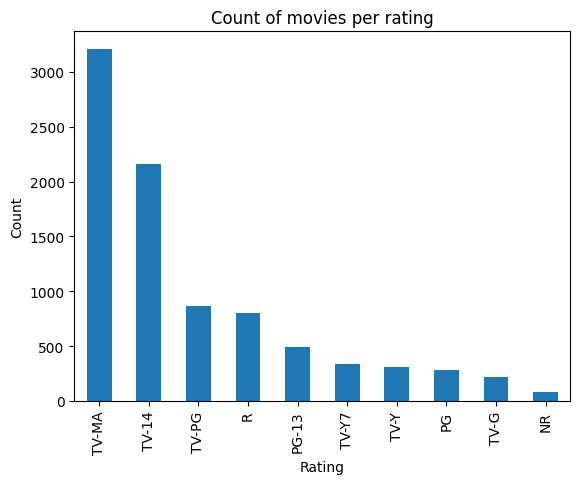

In [ ]:
netflix.drop_duplicates('show_id')['rating'].value_counts(ascending = False).head(10).plot(kind = 'bar')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Count of movies per rating')
plt.show()

###Analysis and Interpretation
  From non graphical analysis using value counts and graphical analysis using count plots, it is observed that the TV-MA rating has the highest count of movies and tv shows in the Netflix. This indicates that the Netflix prefers the content targeted for mature audiences when compared to other rating categories.

##Duration

###a. Non-graphical Analysis:

In [ ]:
netflix.drop_duplicates('show_id')['duration'].value_counts(ascending = False)

,count
duration,
1 Season,1793
2 Seasons,425
3 Seasons,199
90 min,152
94 min,146
...,...
228 min,1
18 min,1
205 min,1


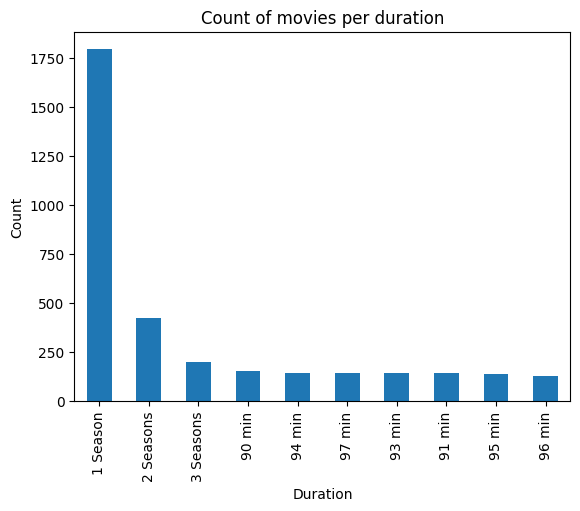

In [ ]:
netflix.drop_duplicates('show_id')['duration'].value_counts(ascending = False).head(10).plot(kind = 'bar')
plt.xlabel('Duration')
plt.ylabel('Count')
plt.title('Count of movies per duration')
plt.show()

Histplot

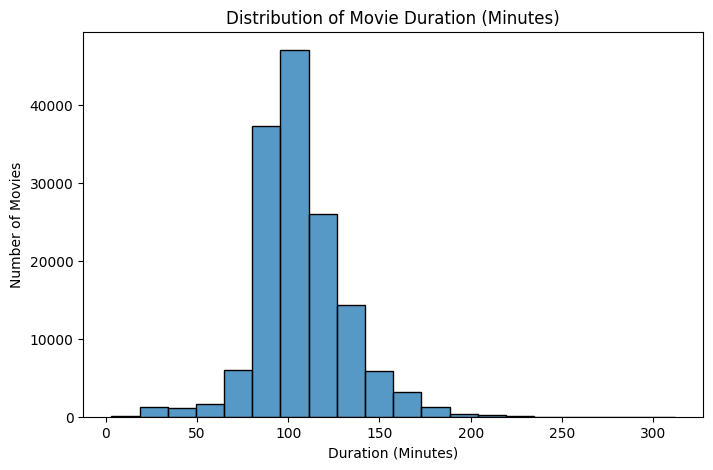

In [ ]:
movies = netflix[(netflix['type'] == 'Movie') &(netflix['duration'].str.contains('min', na=False))].copy()
movies['duration_min'] = movies['duration'].str.replace(' min', '', regex=False).astype(int)
plt.figure(figsize=(8,5))
sns.histplot(movies['duration_min'], bins=20)
plt.title('Distribution of Movie Duration (Minutes)')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')
plt.show()

###Analysis and Interpretation
  From non graphical using value counts and non graphical analysis using count plots, it is observed that the "1 season" is the most common duration for the tv shows in Netflix. This indicates that Netflix has large number of TV shows with single season which may be preferred by those who like consise content.

  The Histogram shows that most movies in netflix has the duration between 80 and 120 mins. This indicates the preference for regular standard length movie.

##Listed in

###a. Non-graphical Analysis:

In [ ]:
netflix['listed_in'].value_counts(ascending = False)

,count
listed_in,
Dramas,29806
International Movies,28243
Comedies,20829
International TV Shows,12845
Action & Adventure,12216
Independent Movies,9834
Children & Family Movies,9771
TV Dramas,8942
Thrillers,7107


###b. Graphical analysis:


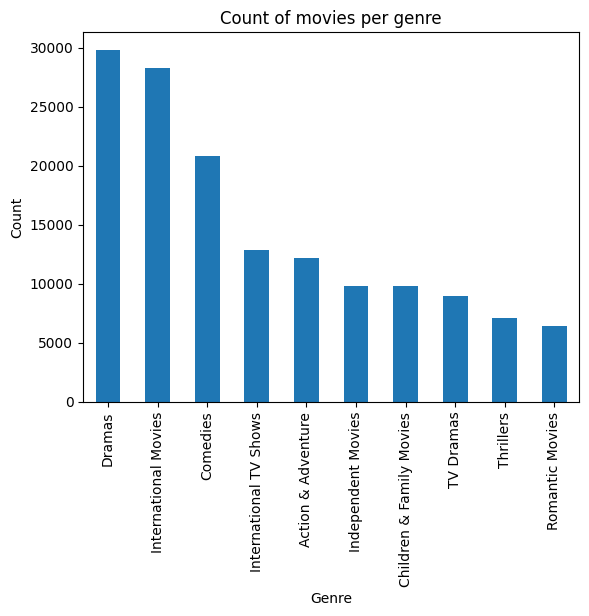

In [ ]:
netflix['listed_in'].value_counts(ascending = False).head(10).plot(kind = 'bar')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Count of movies per genre')
plt.show()

###Analysis and Interpretation
  From non graphical analysis using value counts and graphical analysis using count plots, it is observed that the highest count of movies and TV shows are in the genre "Dramas". This indicate that Netflix has strong emphasis of drama oriented content compared to other genre.

#2. Comparison of tv shows vs. movies.

###a. Find the number of movies produced in each country and pick the top 10 countries.

In [ ]:
top_10_countries = netflix[netflix['type']=='Movie'].groupby('country')['title'].nunique().sort_values(ascending = False).head(10).reset_index().rename(columns={'title':'count'})
top_10_countries


,country,count
0,United States,2752
1,India,962
2,United Kingdom,534
3,Unknown Country,440
4,Canada,319
5,France,303
6,Germany,182
7,Spain,171
8,Japan,119
9,China,114


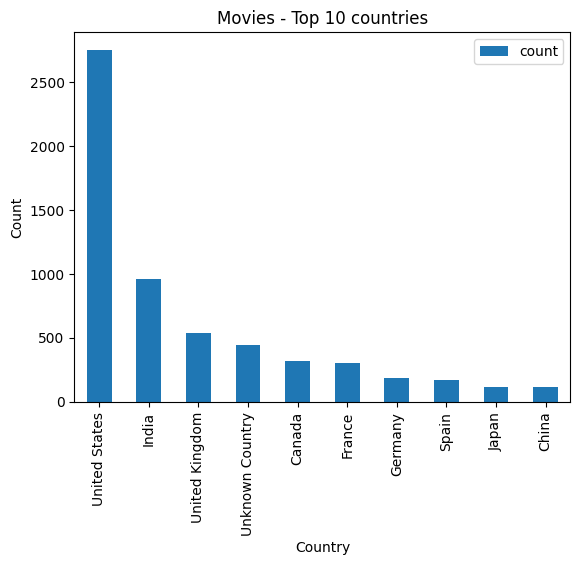

In [ ]:
top_10_countries.plot(kind = 'bar', x= 'country', y = 'count')
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Movies - Top 10 countries')
plt.show()

###Analysis and Interpretation
  From non graphical analysis using groupby, nunique and graphical analysis using count plots, it is observed that the country "United States" has dominated in terms of movies produced and available on Netflix.The list of top 10 countries contributing the highest number of movies are given above.

###b. Find the number of Tv-Shows produced in each country and pick the top 10 countries.

In [ ]:
top_10_tvshows = netflix[netflix['type']== 'TV Show'].groupby('country')['title'].nunique().sort_values(ascending = False).head(10).reset_index().rename(columns = {'title':'count'})
top_10_tvshows

,country,count
0,United States,938
1,Unknown Country,391
2,United Kingdom,272
3,Japan,199
4,South Korea,170
5,Canada,126
6,France,90
7,India,84
8,Taiwan,70
9,Australia,66


Text(0.5, 1.0, 'TV Shows - TOP 10 Countries')

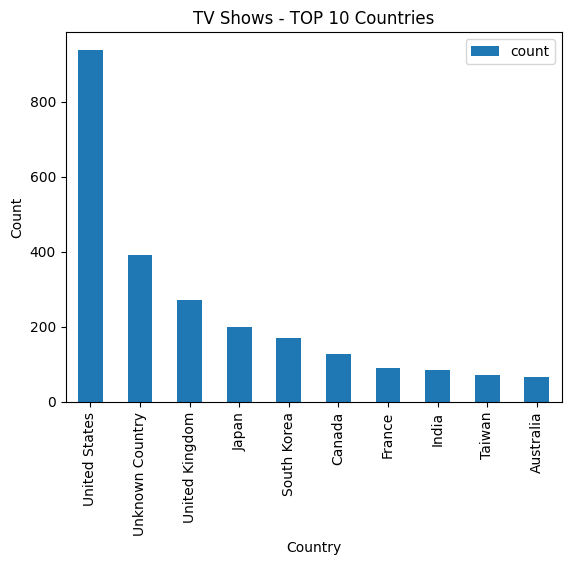

In [ ]:
top_10_tvshows.plot(kind = 'bar', x = 'country', y = 'count')
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('TV Shows - TOP 10 Countries')

###Analysis and Interpretation
  From non graphical analysis using groupby, nunique and graphical analysis using count plots, it is observed that the country "United States" has dominated in terms of TV shows produced and available on Netflix. The list of top 10 countries contributing the highest number of TV shows are given above.

#3. What is the best time to launch a TV show/Movie?


##a. Find which is the best week to release the TV shows/movie.

In [ ]:
netflix['date_added'] = pd.to_datetime(netflix['date_added'], errors= 'coerce')

In [ ]:
netflix['week'] = netflix['date_added'].dt.isocalendar().week

###Best week to launch a Movie


In [ ]:
best_week_movie = netflix[netflix['type']=='Movie'].groupby('week')['title'].nunique().sort_values(ascending = False).head(1)
best_week_movie.reset_index()

,week,title
0,1,316


####Analysis and Interpretation
  From non graphical analysis using groupby, nunique,  it is observed that the week 1 has the highest number of titles added to Netflix platform. This indicates that week 1 is the most common and optimal week to add the movie in Netflix.

###Best week to launch a TV Shows



In [ ]:
best_week_tvshow = netflix[netflix['type']=='TV Show'].groupby('week')['title'].nunique().sort_values(ascending = False).head(1)
best_week_tvshow.reset_index()

,week,title
0,27,85


####Analysis and Interpretation
  From non graphical analysis using groupby, nunique, it is observed that the week 27 has the highest number of titles added to Netflix platform. This indicates that week 1 is the most common and optimal week to add the TV shows in Netflix.

##b. Find which is the best month to release the Tv-show/Movies

In [ ]:
netflix['month'] = netflix['date_added'].dt.month_name()

###Best month to launch a Movie

In [ ]:
best_month_movie = netflix[netflix['type']== 'Movie'].groupby('month')['title'].nunique().sort_values(ascending = False).head(1)
best_month_movie.reset_index()

,month,title
0,July,565


####Analysis and Interpretation
  From non graphical analysis using groupby, nunique, it is observed that the month "July" has the highest number of titles added to Netflix platform. This indicates that the month "July" is the most common and optimal month to add the movie in Netflix.

###Best month to launch TV Show

In [ ]:
best_month_tvshow = netflix[netflix['type']=='TV Show'].groupby('month')['title'].nunique().sort_values(ascending = False).head(1)
best_month_tvshow.reset_index()

,month,title
0,July,254


####Analysis and Interpretation
  From non graphical analysis using groupby, nunique, it is observed that the month "July" has the highest number of titles added to Netflix platform. This indicates that the month "July" is the most common and optimal month to add the TV Shows in Netflix.

#4. Analysis of actors/directors of different types of shows/movies.


##a. Identify the top 10 actors who have appeared in most movies or TV shows.

In [ ]:
top_10_actors = netflix.groupby('cast')['title'].nunique().sort_values(ascending = False).head(10)
top_10_actors.reset_index().rename(columns = {'title':'count'})

,cast,count
0,Unknown Cast,825
1,Anupam Kher,43
2,Shah Rukh Khan,35
3,Julie Tejwani,33
4,Naseeruddin Shah,32
5,Takahiro Sakurai,32
6,Rupa Bhimani,31
7,Akshay Kumar,30
8,Om Puri,30
9,Yuki Kaji,29


###Analysis and Interpretation
  From non graphical analysis using groupby and nunique, it is observed that 'Unknown Cast' dominates the Netflix dataset. This indicates that there is significant number of missing data of cast information. Excluding this category, Anupam Kher has appeared in highest number of movies and TV shows. The list of top 10 actors is mentioned above.

##b. Identify the top 10 directors who have appeared in most movies or TV shows

In [ ]:
top_10_directors = netflix.groupby('director')['title'].nunique().sort_values(ascending = False).head(10)
top_10_directors.reset_index()

,director,title
0,Unknown Director,2634
1,Rajiv Chilaka,22
2,Jan Suter,21
3,Raúl Campos,19
4,Marcus Raboy,16
5,Suhas Kadav,16
6,Jay Karas,15
7,Cathy Garcia-Molina,13
8,Youssef Chahine,12
9,Jay Chapman,12


###Analysis and Interpretation
  From non graphical analysis using groupby and nunique, it is observed that 'Unknown Director' dominates the Netflix dataset. This indicates that there is significant number of missing data of director information. Excluding this category, Rajiv Chilaka has directed highest number of movies and TV shows. The list of top 10 directors is mentioned above.

#5. Which genre movies are more popular or produced more

In [ ]:
from wordcloud import WordCloud
text = netflix['listed_in'].value_counts()

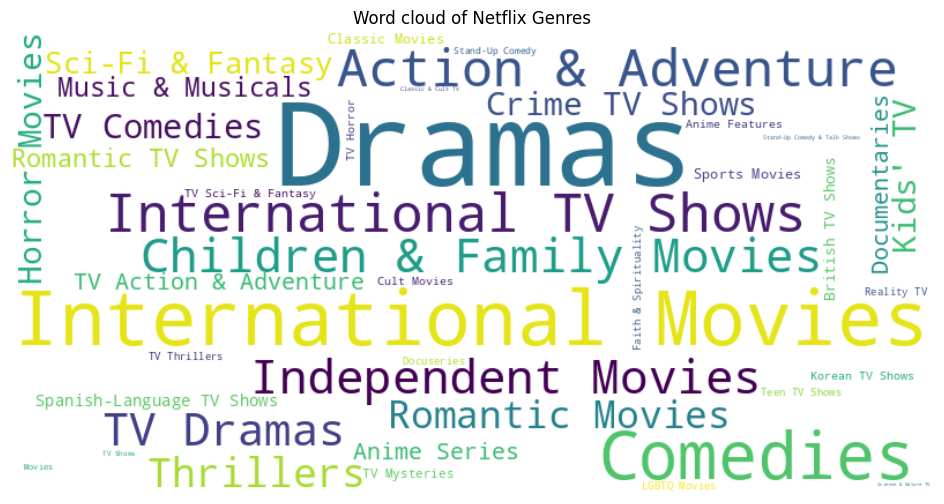

In [ ]:
wordcloud = WordCloud(width= 800, height= 400, background_color= 'white', stopwords= {'Unknown'}).generate_from_frequencies(text)
plt.figure(figsize= (12,6))
plt.imshow(wordcloud, interpolation= 'bilinear')
plt.axis('off')
plt.title('Word cloud of Netflix Genres')
plt.show()

###Analysis and Interpretation
  From graphical analysis using worldcloud, it can be observed that the genre "Dramas" appears in the largest font size in the word cloud. This indicates that the genre has highest frequency of occurence in the Netflix dataset.
  This shows that there is a strong and consistent audience for drama based content

#6. Find After how many days the movie will be added to Netflix after the release of the movie (you can consider the recent past data)

In [ ]:
netflix['release_year'] = pd.to_datetime(netflix['release_year'].astype('str'), format= '%Y')
movies_df = netflix[netflix['type']== 'Movie'].drop_duplicates('show_id')
recent_movies = movies_df[movies_df['release_year']>= '2018-01-01'].copy()
recent_movies['date_to_add']  = (recent_movies['date_added'] - recent_movies['release_year']).dt.days
recent_movies = recent_movies[recent_movies['date_to_add']>0]
best_time_to_add = recent_movies['date_to_add'].mode()[0]

In [ ]:
print(best_time_to_add)

334


###Analysis and Interpretation
  From non graphical analysis using mode of time difference between date added and release year, it is observed that the optimal time to add new content is after 334 days after the release date. Since the dataset has release date has only release year , default date of January 01 of the year ("YEAR-01-01") was assumed for analysis. The mode of the difference between release date and date added was applied.

#Business Insights


1. Movies Dominate the Netflix content library

      The movies are nearly 3 times more than the TV shows which clearly shows that the Netflix focuses more of movies than TV shows.
      
2. Dramas are most popular genre on Netflix.

      Based on the analysis using word cloud, the Dramas are most prefered genre on Netflix which suggest that there is strong audience for drama based content.

3. The United states is the leading content producer.

      The United States produces highest number of movies and TV shows available on Netflix. This is followed by India. This highlights the significance of these markets for Netflix.

4.  Netflix content addition has increased significantly in recent years

      The content addition by Netflix has raised significantly after 2016, indicating Netflix aggressive expansion and investment

5.  TV shows are more recent

      The Boxplot analysis shows that the TV shows are more recent than movies suggesting that the Netflix is investing in newer TV show content.

6.  Most movies have standard duration

      The histogram analysis shows that the duration for most movies are between 80 and 120 mins which represent the standard movie duration.

7.  January and July are key period for releasing new content

      Analysis of week and month of content addition indicate that the week 1 and July month has highest number of title additions which indicates the preferred releasing window.

8.  Movies addtion on Netflix within a year

      The mode of difference between release year and date added is approximately 334 days which indicate that the movies are added within a year of release.



#Recommendations

Based on the above Business insights, the following actionable recommendations are suggested:

1.  Increase investment in drama content

      Since the drama content consistently show high presence on Netflix, Netflix should produce and continue to acquire more drama based content on Netflix to meet audience demand.

2.  Strength content production in key markets

      The Netflix should increase content production in countries such as United States and India since these countries contribute significantly to the platform.

3.  Produce newer TV show content

      Since the there is more trend for newer TV shows, Netflix should invest in more newer tv shows with limited series content

4.  Plan major release during peak month

      Netflix should plan major content release during the month of January and July for increasing the customer engagement.

5.  Improve metadata quality

      Netflix should improve the metadata quality by reducing the missing informations of cast, directors, date added and ratings to increase the user experience.

6.  Focusing on Standard length movies

      Netflix should focus on producing the movies of standard length between 80 and 120 mins as preferred by the viewers.

7.  Invest in TV-MA content

      Since there is a huge audience for TV-MA rated content, Netflix should focus on producing more TV-MA rated content